In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/CC GENERAL.csv')

In [ ]:
df.head(
)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


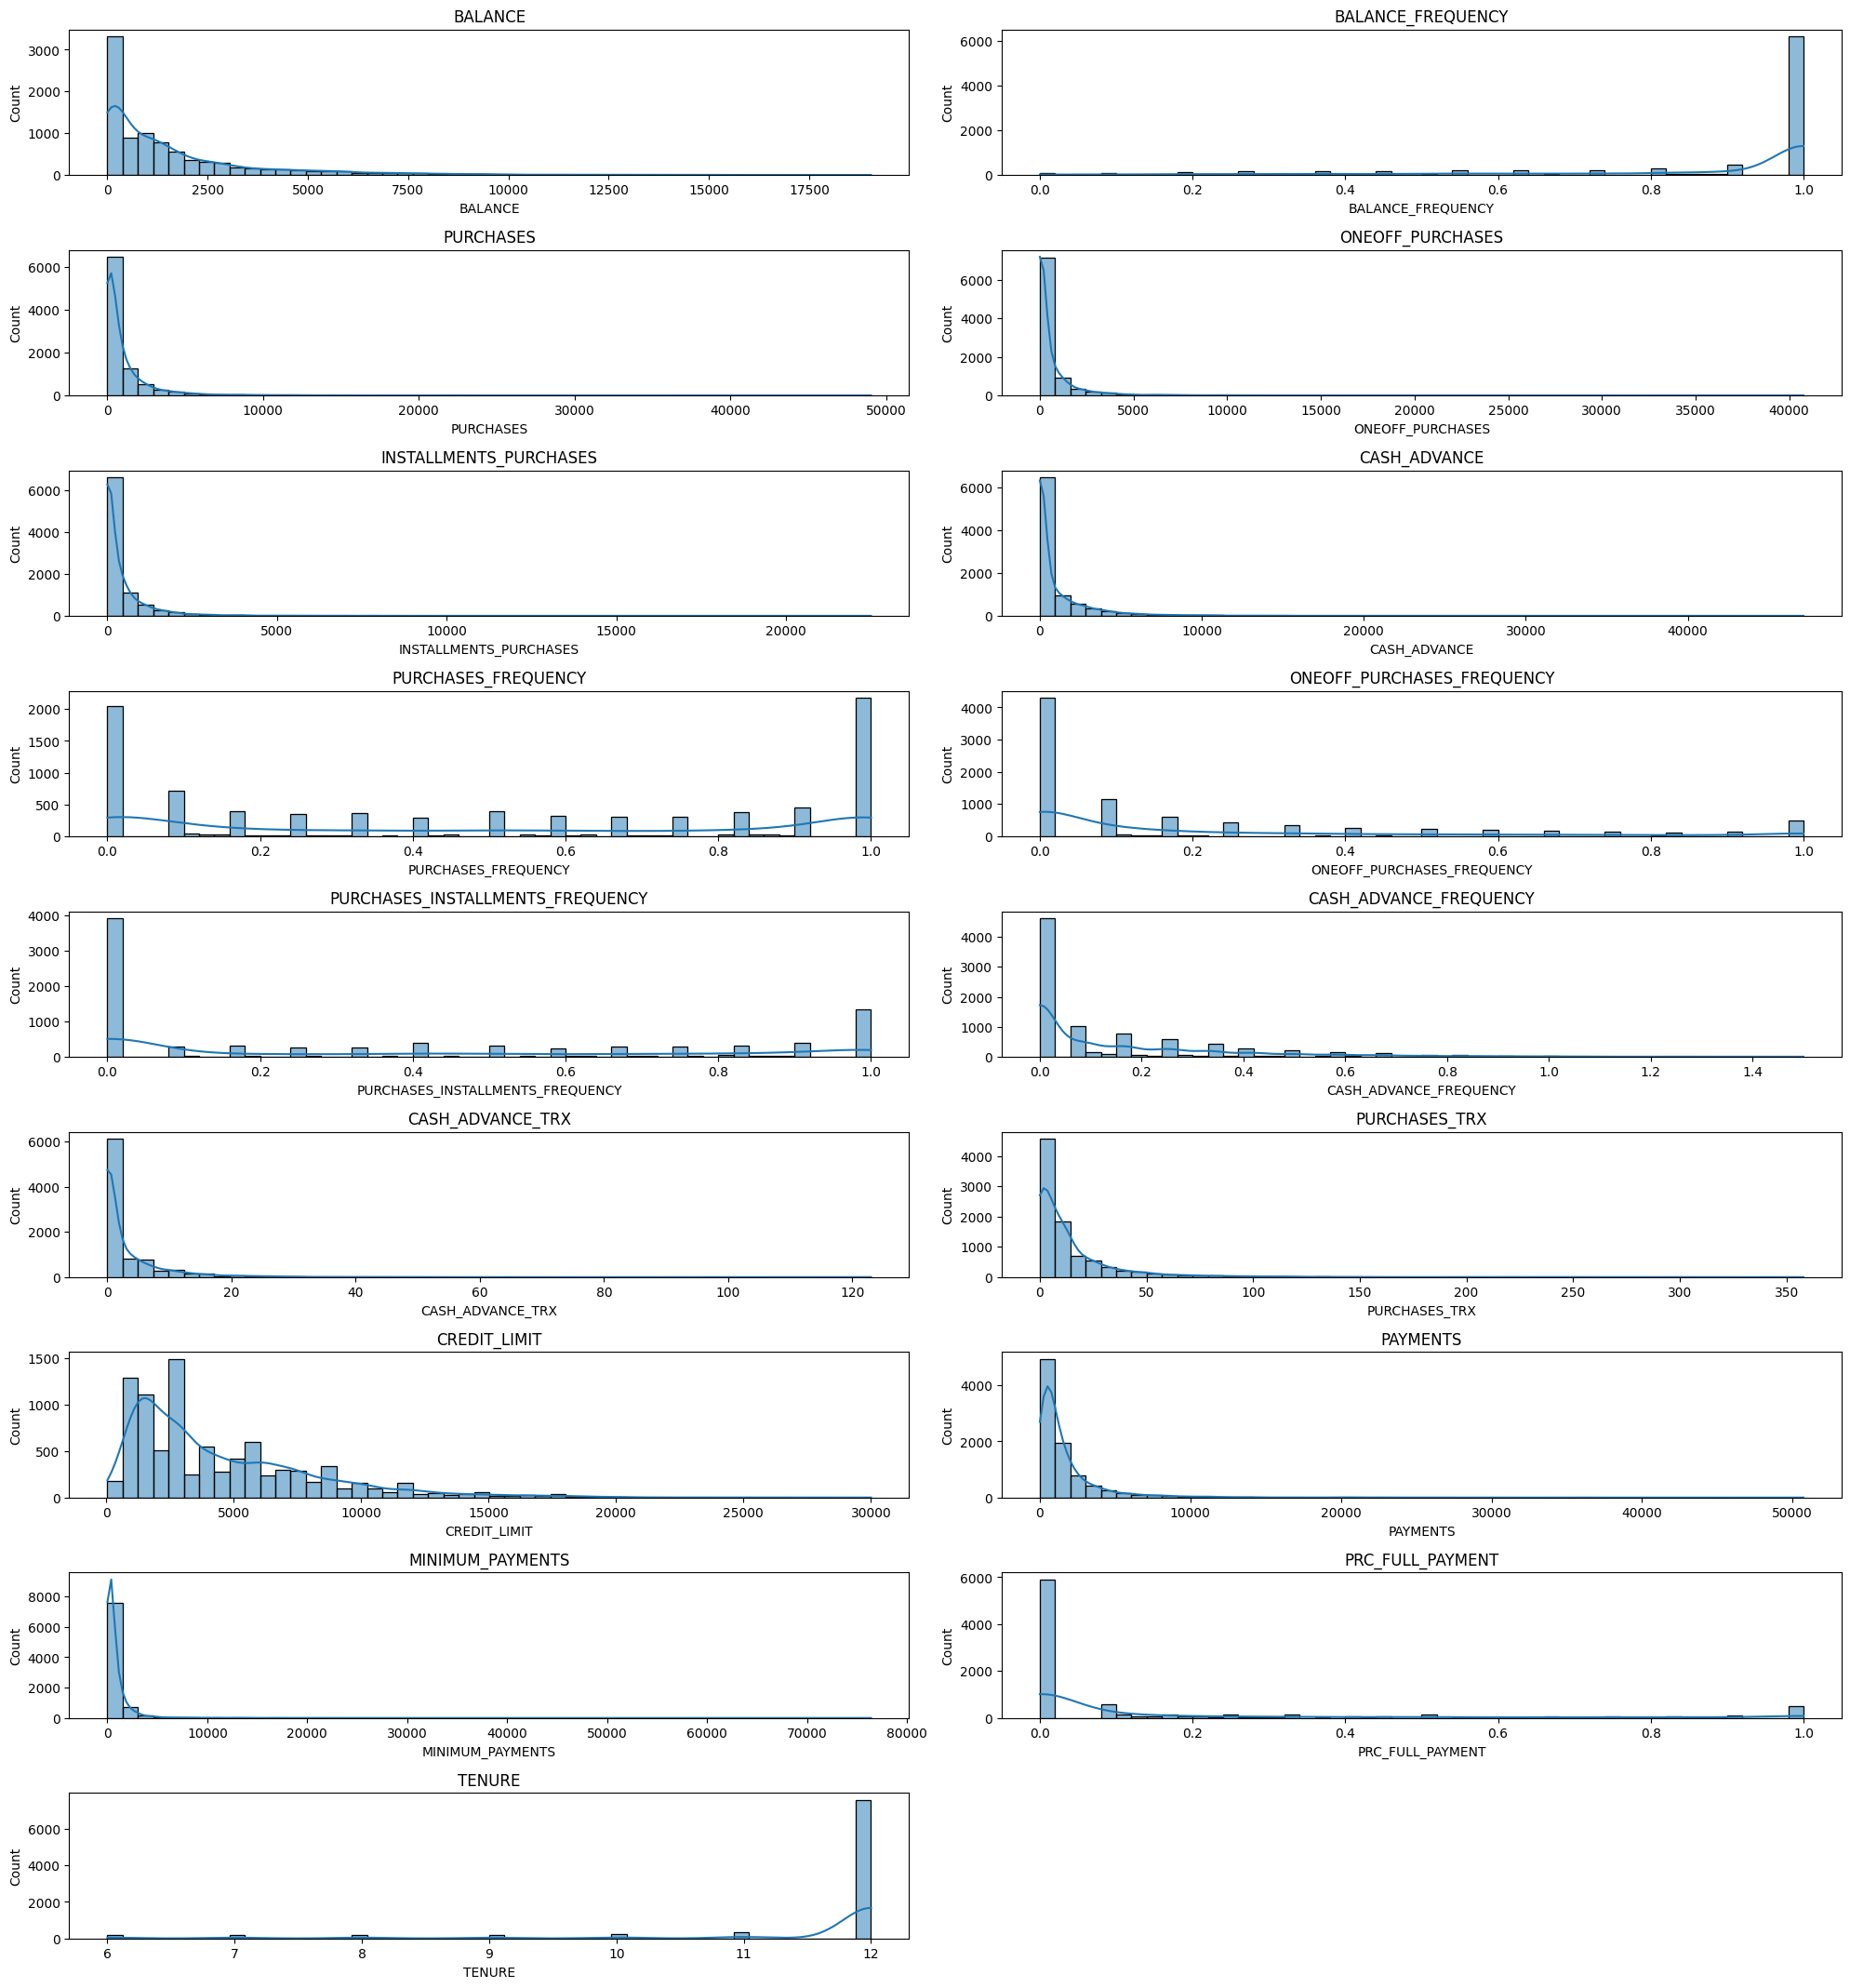

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("CC GENERAL.csv")

# drop ID column
df_plot = df.drop('CUST_ID', axis=1)

# plot distributions
plt.figure(figsize=(20,40))

for i, col in enumerate(df_plot.columns, 1):
    plt.subplot(len(df_plot.columns), 2, i)
    sns.histplot(df_plot[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

# fill missing values (if not already done)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

# remove id
X = df.drop('CUST_ID', axis=1)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


/tmp/ipython-input-2657293075.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
/tmp/ipython-input-2657293075.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)


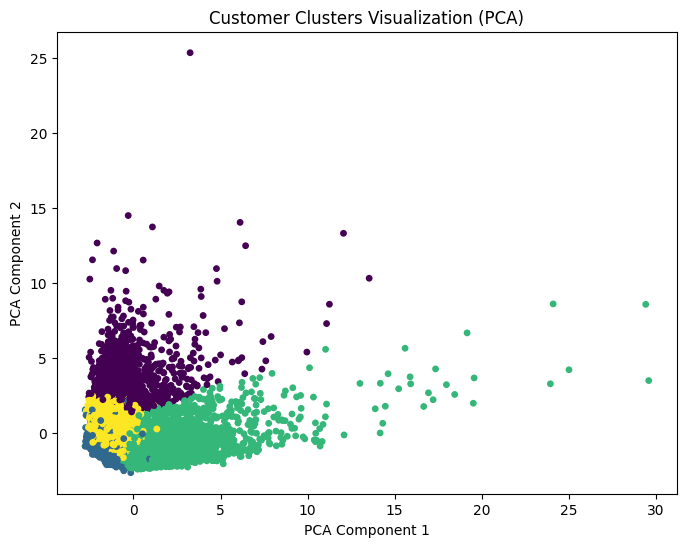

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=15)
plt.title("Customer Clusters Visualization (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


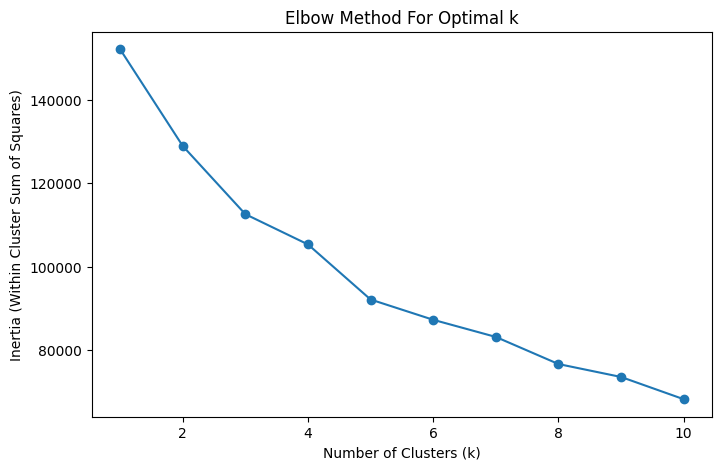

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

# try multiple k values
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within Cluster Sum of Squares)")
plt.title("Elbow Method For Optimal k")
plt.show()


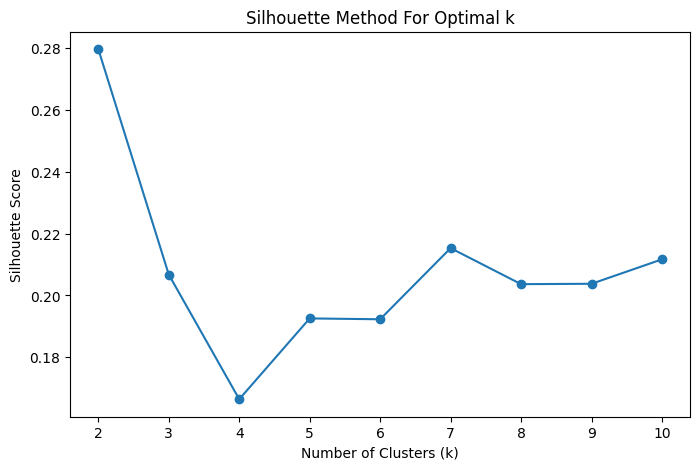

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(K, scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method For Optimal k")
plt.show()


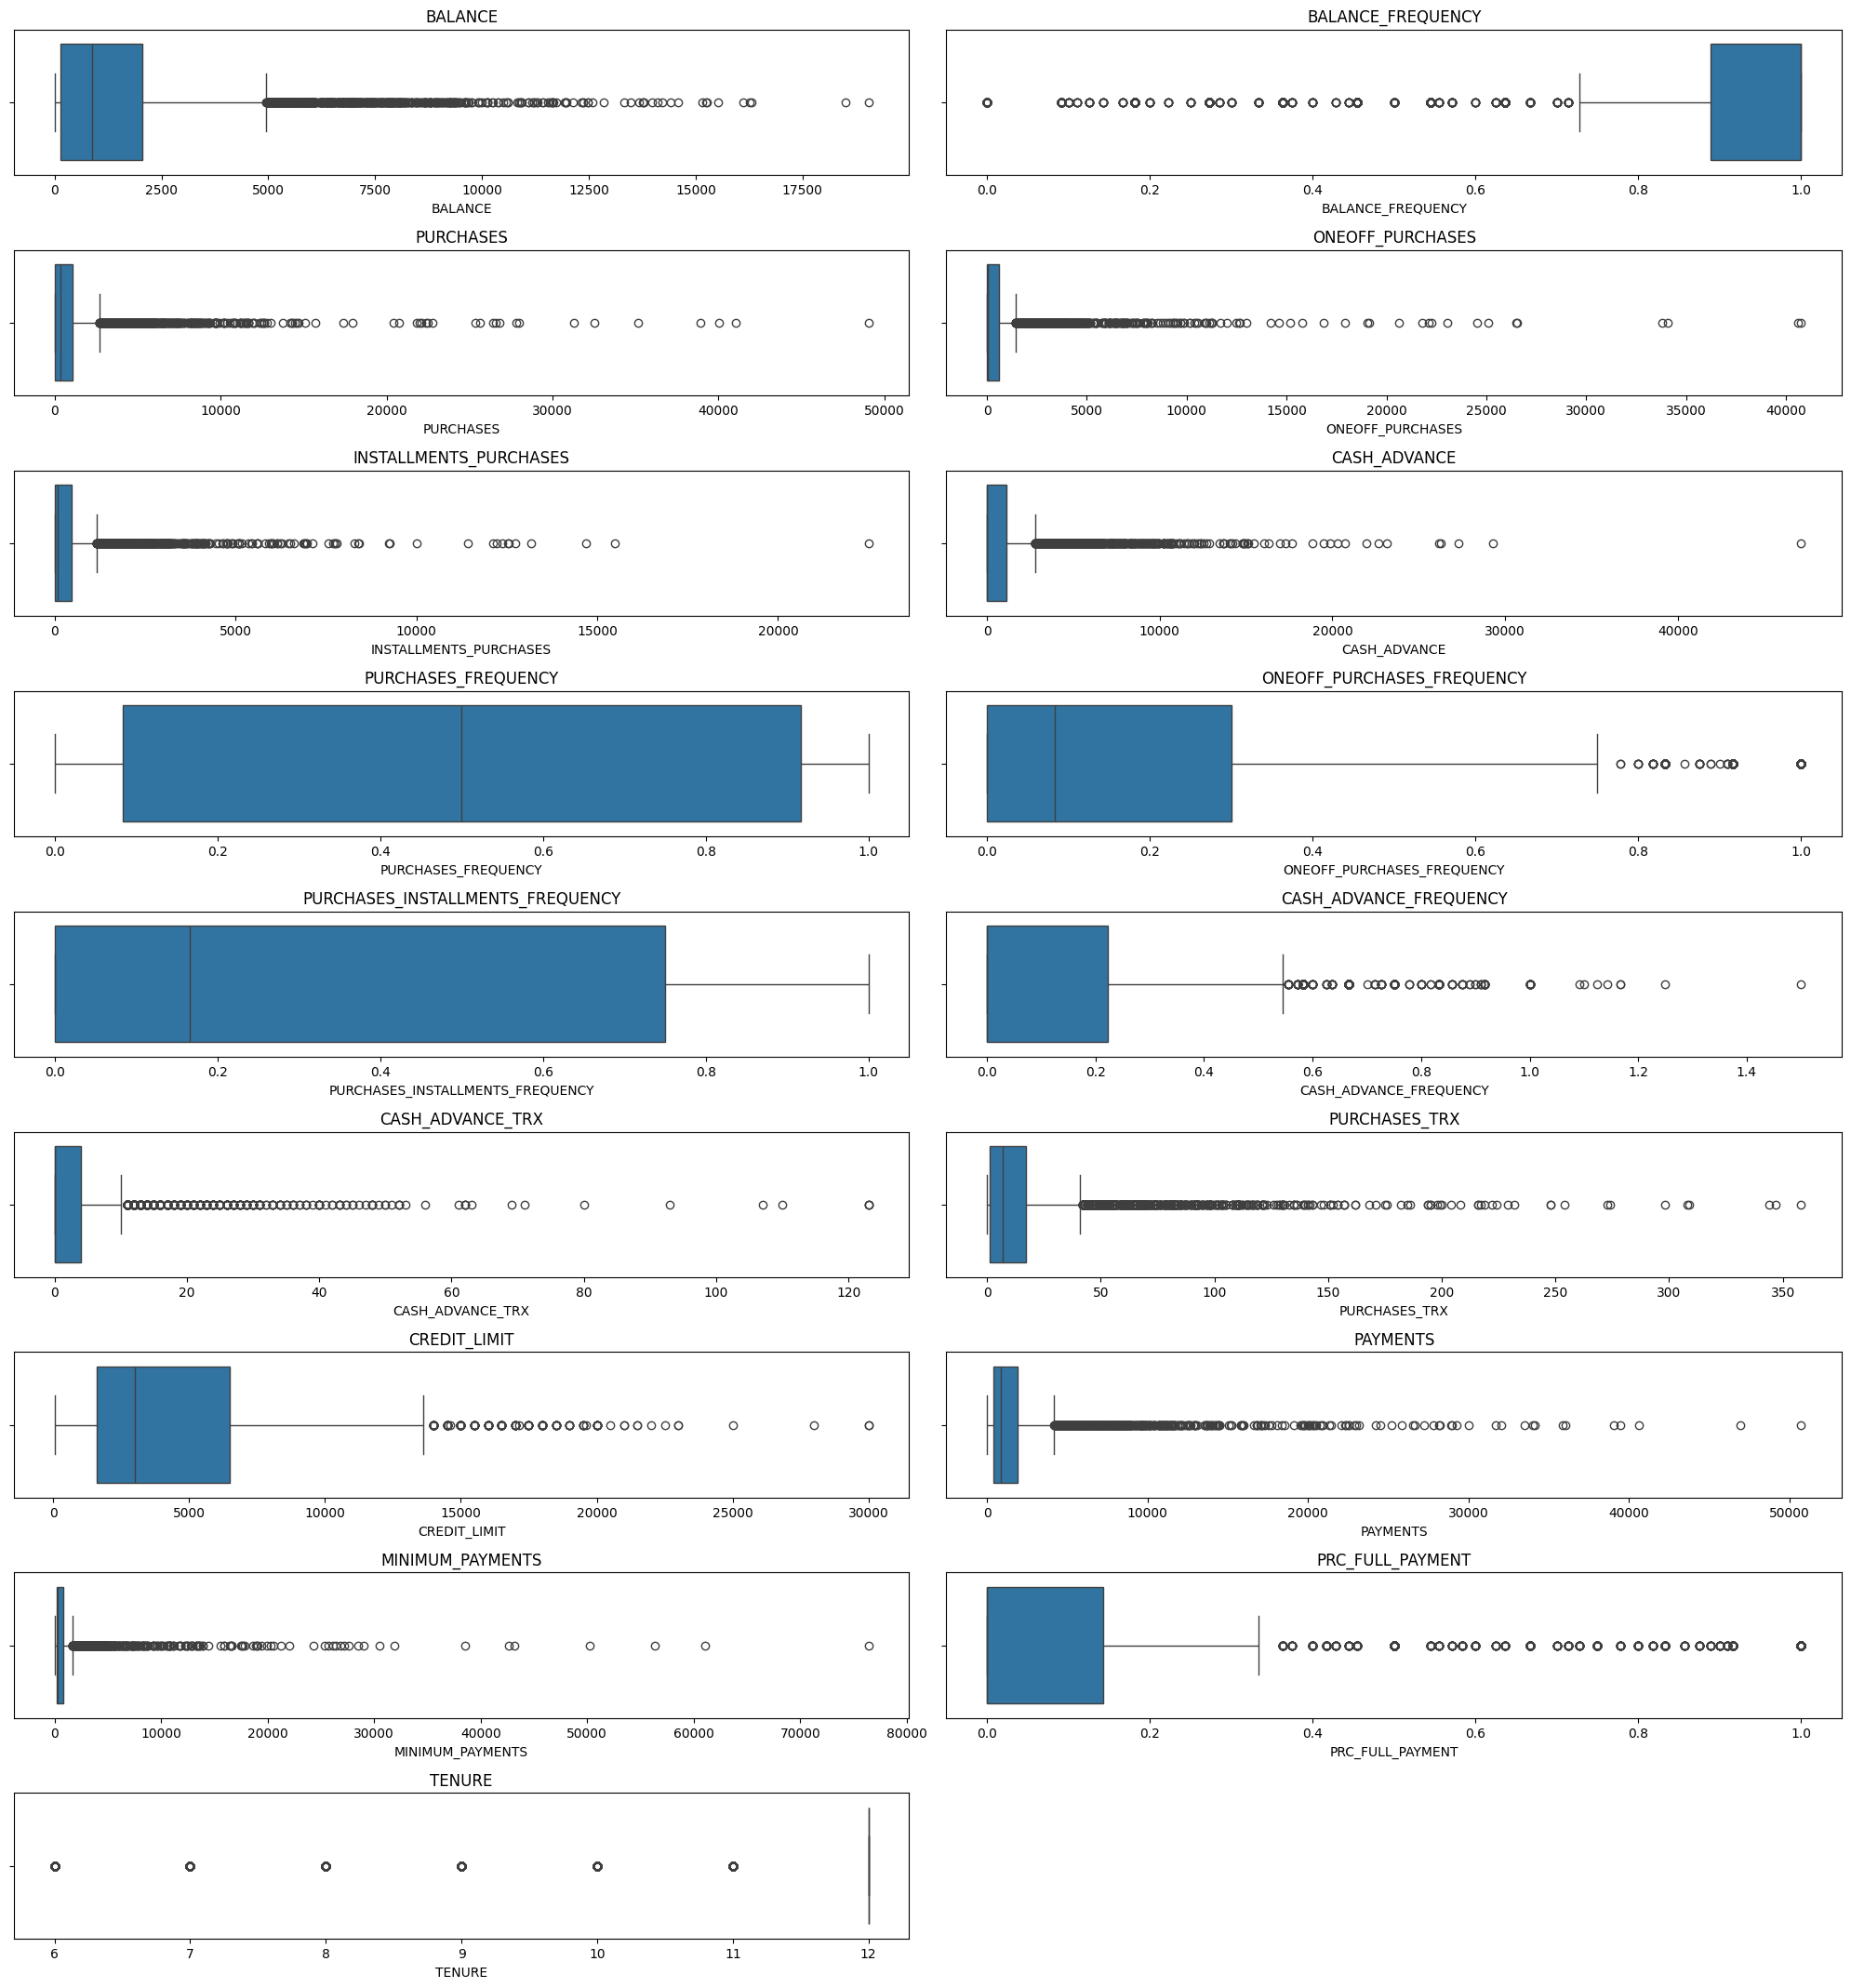

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,40))

for i, col in enumerate(X.columns, 1):
    plt.subplot(len(X.columns), 2, i)
    sns.boxplot(x=X[col])
    plt.title(col)

plt.tight_layout()
plt.show()


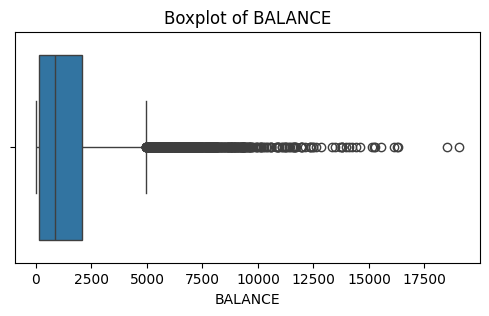

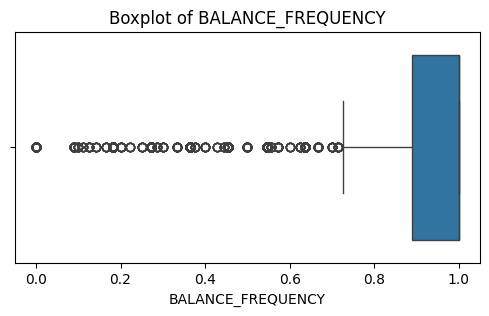

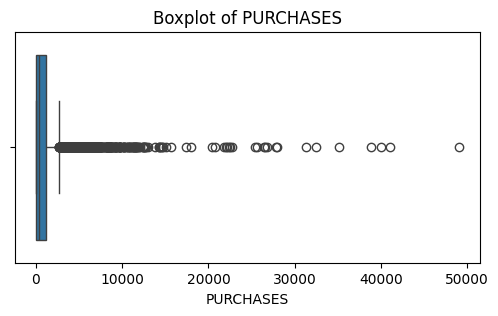

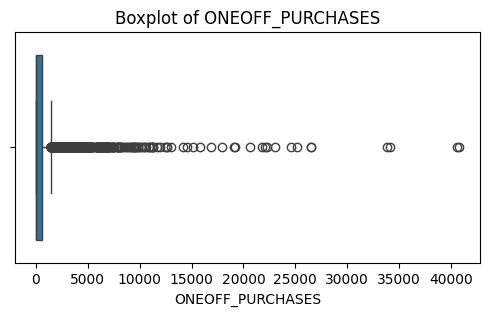

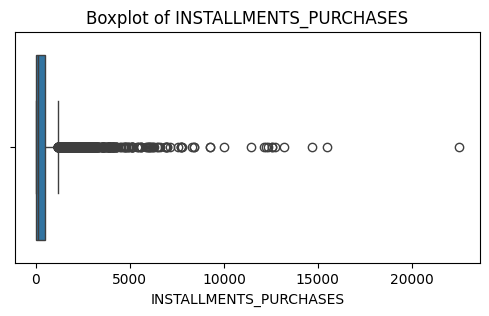

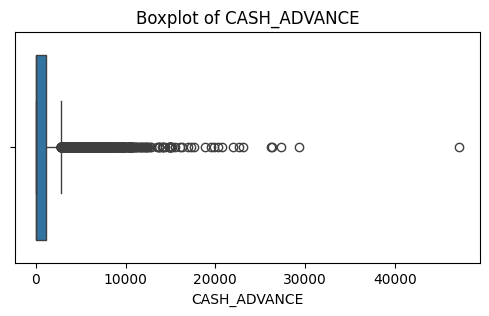

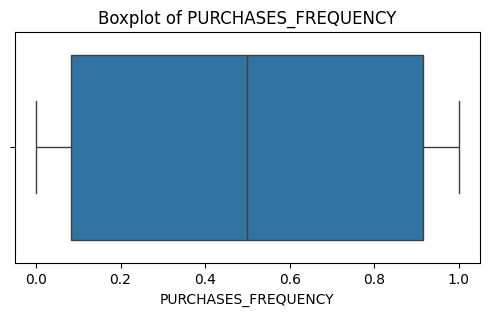

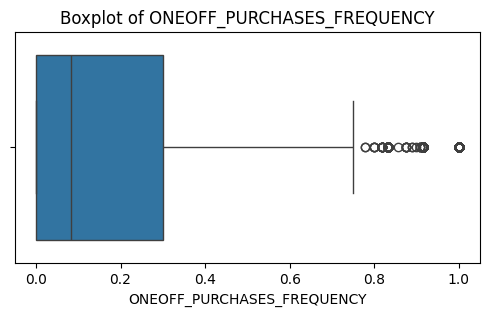

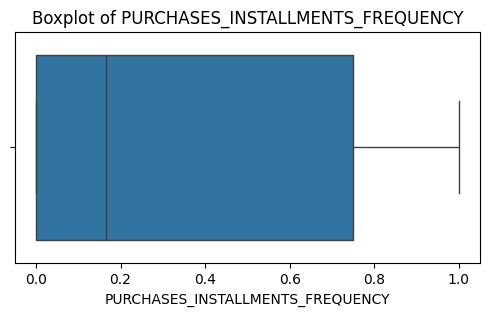

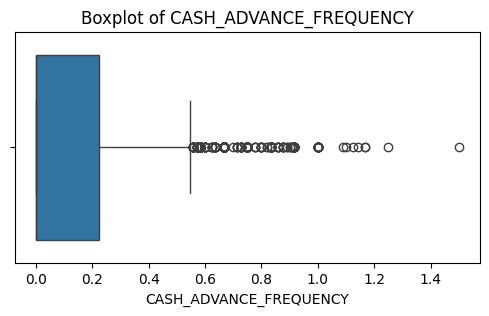

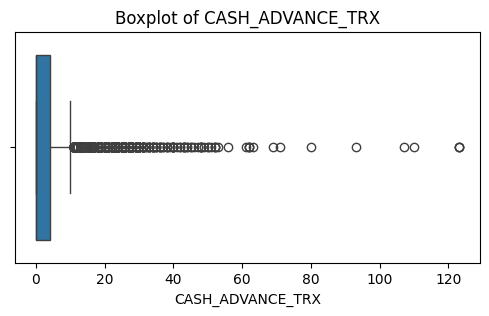

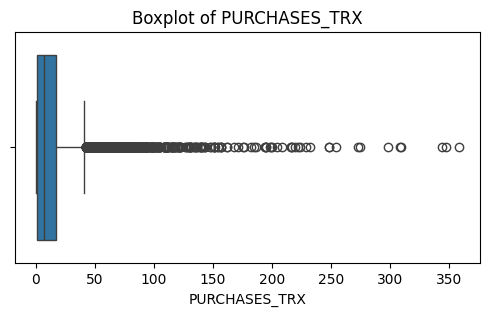

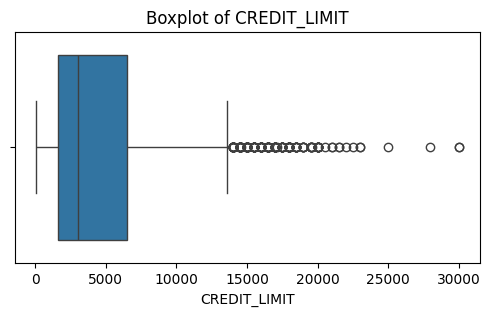

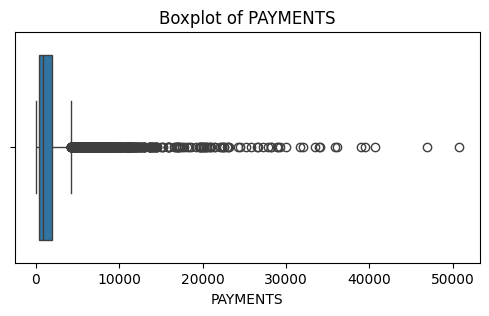

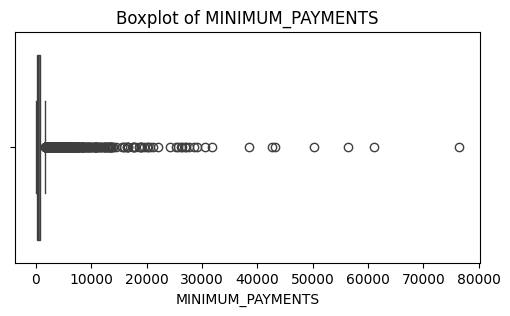

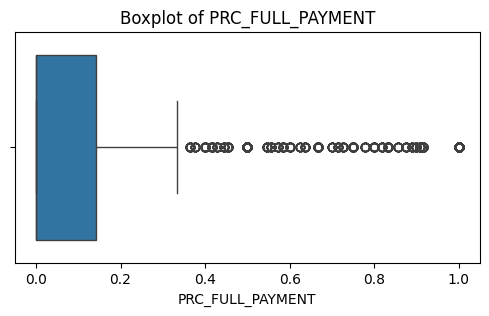

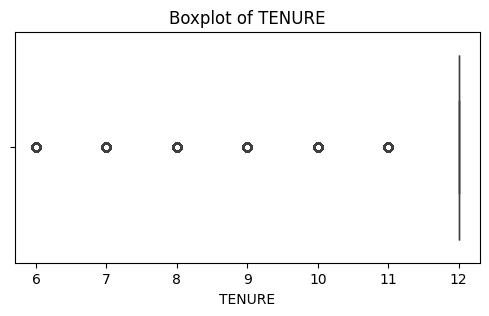

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

for col in X.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=X[col])
    plt.title(f"Boxplot of {col}")
    plt.show(block=False)   # show figure

    plt.pause(2)            # show for 2 seconds (change if needed)
    plt.close()             # close before next


In [ ]:
import numpy as np

X_capped = X.copy()

for col in X_capped.columns:
    Q1 = X_capped[col].quantile(0.25)
    Q3 = X_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_capped[col] = np.clip(X_capped[col], lower, upper)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)


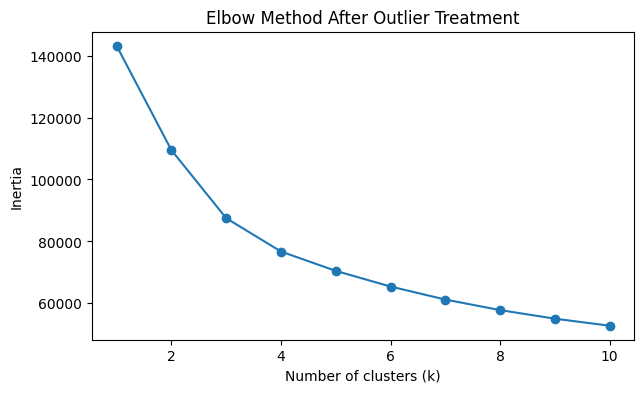

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method After Outlier Treatment")
plt.show()


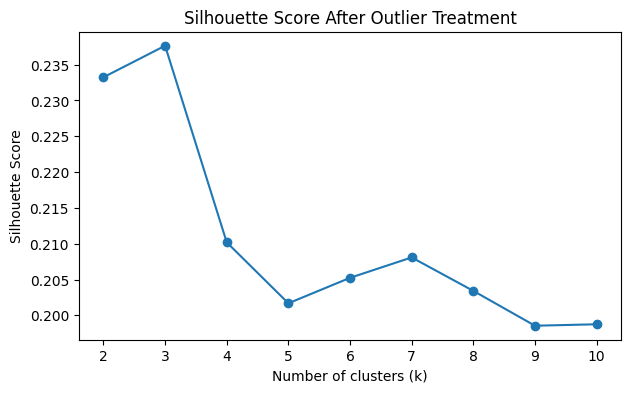

In [ ]:
from sklearn.metrics import silhouette_score

scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(7,4))
plt.plot(K, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score After Outlier Treatment")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [ ]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True).round(2)
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1967.49,0.98,3233.61,1999.38,1234.57,582.03,0.91,0.55,0.69,0.08,1.86,43.72,6622.70,3318.08,1126.03,0.24,11.86
1,563.66,0.80,391.69,181.89,210.21,176.37,0.46,0.11,0.35,0.04,0.67,7.41,3068.80,735.28,442.20,0.18,11.44
2,3212.32,0.95,246.85,165.04,81.85,2940.02,0.19,0.08,0.11,0.37,9.65,3.57,5460.04,2324.76,1402.25,0.03,11.38


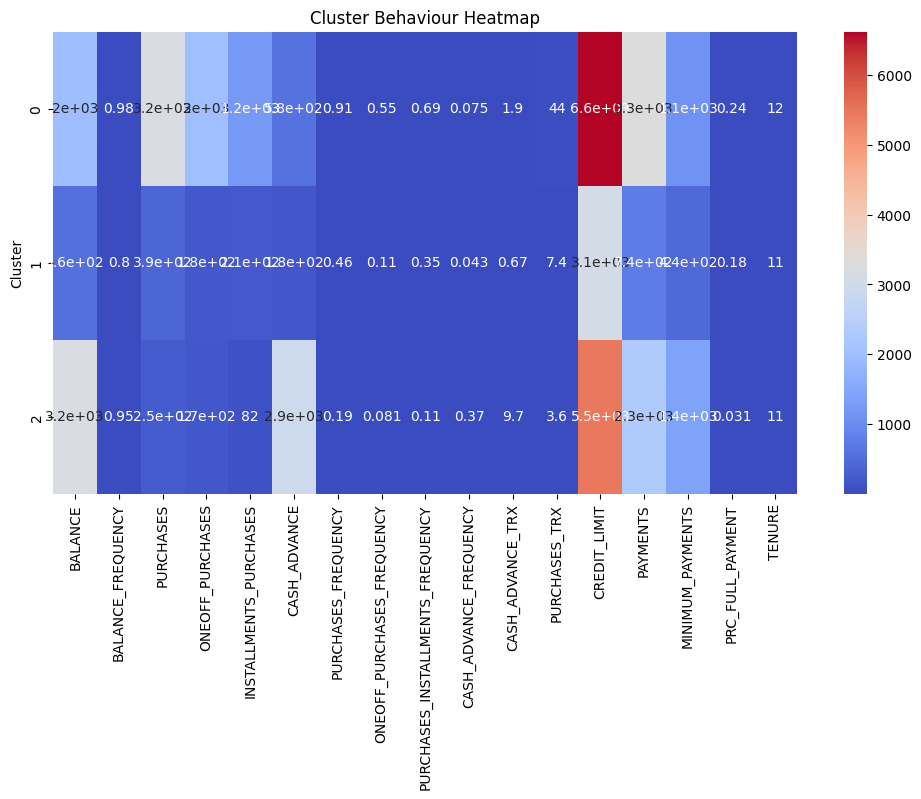

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(cluster_profile, annot=True, cmap='coolwarm')
plt.title("Cluster Behaviour Heatmap")
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert scaled data to dataframe (helps plotting)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# PCA to 2D
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(pca_components, columns=['PC1','PC2'])
pca_df['Cluster'] = df['Cluster']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


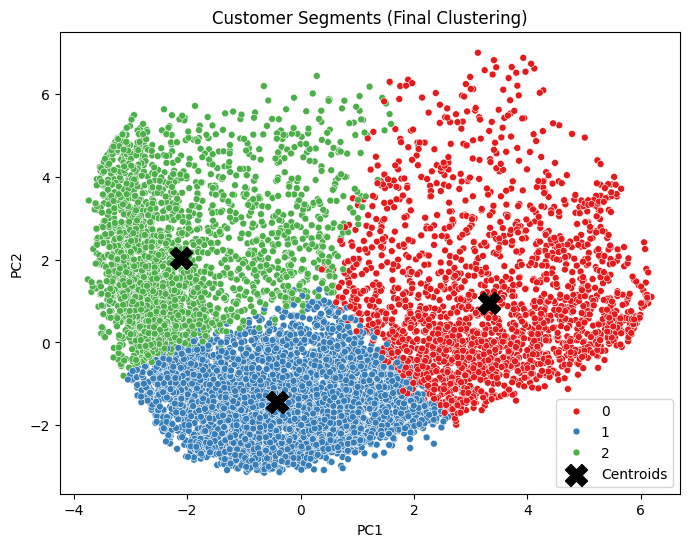

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=25
)

# Plot centroids
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1],
            s=250, c='black', marker='X', label='Centroids')

plt.title("Customer Segments (Final Clustering)")
plt.legend()
plt.show()
